## Work package 1.2 
### This notebook demonstrates running water quality measures using a multi-sensor approach, for an area of interest.
Note that:
- an area / domain of interst is assumed as a start point
- the processing resolution is determined from the space-time size of the AOI, in part to remain within sandbox memory limitations
- 
### An additional water mask is needed here AFTER the FAI and NDVI steps, to limit annual water analysisi to areas that are likely water in that year
e.g. an adjusted annual water frequency of 0.75. This will prevent areas that have dried up being included in the water quality algs.



### Dependencies etc.

In [56]:
# --- --- 
import datacube
import numpy as np
import xarray as xr
import scipy as sp
import gc
from scipy import stats
import pandas as pd

from deafrica_tools.plotting import display_map, rgb

dc = datacube.Datacube(app='DoinWhatImdoin') #testing what difference the 'app' value makes...

In [57]:
# --- pathnames 
WP12              = '/home/jovyan/dev/deafrica_water_quality/WP1.2'
WP22              = '/home/jovyan/dev/deafrica_water_quality/WP2.2'
data_directory    = '/home/jovyan/dev/deafrica_water_quality/src/water_quality/data/'
distributions_filename = 'measurement_distributions.csv'
lookup_table_filename  = 'targ_ref_lookup.csv'
np_parameters_filename = 'normalisation_parameters.csv'


In [58]:
# --- run code for functions that are called
%run _WQ_functions.py
# --- notebook _Build_annual_datasets should be redundant now ...
#%run _Build_annual_dataset-1.0.ipynb   #for now I have kept these functions in a notebook for the markdown

In [59]:
# --- controlling parameters and settings
verbose = True
test    = False
# --- set according to memory limits; 10000 pixels is enough to characterise a water body
max_cells = 100000   
max_cells = 10000   

In [60]:
# --- Choose the waterbody - parameters are retreived from a dictionary ---
places_dict     = set_spacetime_domain()   
# --- extract an AOI for a given placename (could iterate through the dictionary keys as an alternative)
placename = 'Lake_Sulunga'   
placename = 'Ghana_River'   
placename = 'Lake_Tikpan'   
placename = 'Lake_vic_turbid'   
placename = 'SA_smalldam'   
placename = 'SA_smalldam1' 
placename = 'Lake Awassa'
placename = 'Lake Ziway'
placename = 'Lake Elmenteita'
placename = 'Lake Chamo'
placename = 'Lake_vic_algae'
placename = 'Lake_Manyara'
placename = 'SA_smalldam'   
placename = 'Lake_vic_algae'
placename = 'Haartbeesport_dam'
placename = "Lake_Baringo"
# --- the functions set_spacetime_domain is used here to set/retrieve a bunch of processing parameters
# --- when operationalising, this must be replaced but an approach that iterates through tiles or waterebodiies

spacetime_domain, grid_resolution, cell_area, resampling_option, year1, year2 \
                           = set_spacetime_domain(placename,'2000','2024',max_cells,verbose,False)     

Lake_Baringo AOI:  {'x': (36.0, 36.17), 'y': (0.45, 0.74), 'time': ('2000', '2024')} Lake Baringo
Grid resolution will be: (220, 220)
Rough dimensions (x,y):  16  by  28 kilometres
Total cells is roughly:  10185
Cell area is:  0.0484  km2
Resampling : nearest
Site name:  Lake Baringo
Years: 2000 2024


In [61]:
#from importlib.resources import files
#from odc.geo.geobox import GeoBox
from odc.geo.geom import Geometry
import geopandas as gpd

place_name = "Lake_Baringo"
places_fp = "../src/water_quality/data/places.parquet"
places_gdf = gpd.read_parquet(places_fp)
place = places_gdf[places_gdf["name"].isin([place_name])]
aoi_geom = Geometry(geom=place.iloc[0].geometry, crs=place.crs)

#tile_geobox = GeoBox.from_geopolygon(aoi_geom, crs=CRS('EPSG:6933'), resolution=Resolution(x=10, y=-10))
#tile_geobox = GeoBox.from_geopolygon(aoi_geom, crs='EPSG:6933', resolution=10)
#tile_geobox

In [62]:
# --- save the analysis parameters in a dictionary 
y1,y2 = pd.DatetimeIndex([spacetime_domain['time'][0],spacetime_domain['time'][1]]).year[[0,1]]
parameters = {}
parameters['placename'] = placename
parameters['xyt'] = spacetime_domain
parameters['grid_resolution'], parameters['cell_area'], parameters['resampling_option'],parameters['year1'],parameters['year2'] = \
        grid_resolution,                   cell_area,                resampling_option,            y1,y2


### Build a multi-sensor dataset 
- flexibility is key here, and consistent naming so that measurements from multiple sensors can be unambiguously included in a single dataset for analysis
- keeping all data in a single dataset simplifies subsequent steps and retains flexibility, e.g., to add in new water quality algorithms
- a dictionary of instruments and sensors is used to rename all measurements to a common form
- since we are using annual geomedians, we don't need to harmonise dates, at this point, except for when using temperature data
- the approach is designed to be extendable to monthly composites

#### Set a list of 'instruments' to be used in the analysis. Once methods are all in place this will not change except to support improvements.
- instrument names are used rather than satellite names, to avoid confusion
- For these purposes, wofs is also an instrument name.
- The list is set up to be resuable when we move from geomedians to monthly composites

In [63]:
# --- set which instruments to use (this is checked later against the date range for each place)
# --- for Phase1, mapping, the main datasets are the geomedians. For monioring the local time-seres will be brought in as well as the geomedians.
# --- temperature is yet to be included.

instruments_to_use = {
    'oli_agm'  : {'use': True },
    'oli'      : {'use': False},
    'msi_agm'  : {'use': True },
    'msi'      : {'use': False},
    'tm_agm'   : {'use': True },
    'tm'       : {'use': False},
    'tirs'     : {'use': False},  
    'wofs_ann' : {'use': True },
    'wofs_all' : {'use': False },  # wofs_all will be removed as it is better to derive from wofs_ann
    }

#instruments_to_use = _instruments_to_use.copy()  #using a copy is helpful sometimes..

# --- don't try to use instruments for which there are no data 
instruments_to_use = check_instrument_dates(instruments_to_use,int(year1),int(year2),verbose=False)

In [64]:
grid_resolution = 100
resampling_option = "bilinear"

In [65]:
spacetime_domain = {'geopolygon':aoi_geom, 'time': ('2012', '2023')}

In [66]:
# --- build the multivariate/multi-sensor dataset. 
#     Datacube calls are made to extract the primary data. 
#     Variables are-re-named and merged to a single dataset ---

ds             = build_wq_agm_dataset(spacetime_domain,
                                      grid_resolution,
                                      resampling_option,
                                      instruments_to_use,
                                      verbose = verbose)

# --- retain a dictionary of the instruments and measurements that are on-hand ---
instruments    = instruments_list(instruments_to_use)[0]  # a list of the instruments  in use
            


Building the dataset:
loading data for  oli_agm ...
loading data for  msi_agm ...
loading data for  tm_agm ...
loading data for  wofs_ann ...


In [67]:
#ds.time.attrs=[]

In [68]:
#export the dataset as an input for the next step:
#ds.to_netcdf("./"+placename+"_raw.nc")

### Determine pixels that are water (sometimes, usually, permanent)

In [69]:
# --- controling parameters for water mapping on a pixel by pixel basis ---
WFTH = water_frequency_threshold_high = 0.5    #this threshold targets areas that are as like as not to be water at any time.
WFTL = water_frequency_threshold_low  = 0.1    #for pixel processing (rather than during summation)
PWT  = permanent_water_threshold      = 0.875  #used to map annual permanent water (value arrived at through testing)
SC   = sigma_coefficient              = 1.2    #used to map annual permanent water (value arrived at through tessting)
ds   = water_analysis(ds,
                   water_frequency_threshold= WFTH,
                   wofs_varname             = 'wofs_ann_freq',
                   permanent_water_threshold= PWT,
                   sigma_coefficient        = SC,
                   verbose                  = True,
                   test                     = test)

/opt/venv/lib/python3.12/site-packages/xarray/core/duck_array_ops.py:250: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


### 5yr wofs frequency. 
#### A 5-year wofs frequency is needed to correctly identify the extent of water despite low wofs frequencies caused by floating vegetation. 

In [70]:
# --- calculate the 5-year frequency 
ds = WOFS_5_year_frequency(ds,False)

In [71]:
# --- create a 5-year water mask ---
ds['water_5yr'] = xr.where(ds.wofs_5yr_freq>0.45,ds.wofs_5yr_freq.astype('bool'),np.nan)


In [72]:
# --- Initiate a results dictionary containing the analysis parameters and the results
results = {}
results['parameters'] = parameters

#The annual water area can be saved as a pandas data frame with years as indexes:
results['annual_results'] = pd.DataFrame(
    {
     "time"    :ds.time,
     "year"    :pd.DatetimeIndex(ds.time).year,
     "area_km2":(ds.water_5yr.count(dim=('x','y'))*parameters['cell_area']).round(2)},     
    #index = pd.DatetimeIndex(ds_annual.time).year
    )

ds['agm_count']=('time','y','x'),np.zeros((ds.sizes['time'],ds.sizes['y'],ds.sizes['x']))

for instrument in 'oli_agm','tm_agm','msi_agm':
    if instrument in ds.data_vars:
        ds['agm_count'] = ds['agm_count'] + ds[instrument+'_count'].where(ds[instrument]==True,0)
        results['annual_results'].insert\
            (
            2,
            instrument,
            (ds[instrument])
            )

results['annual_results'].insert\
            (
            results['annual_results'].columns.size,
            'total_geomedian_count',
            ds['agm_count'].mean(dim=('x','y')).round()
            )


results['annual_results'].insert\
            (
            results['annual_results'].columns.size,
            'average_water_freq',
            (ds.wofs_ann_wetcount/ds.wofs_ann_clearcount).where(ds.water_5yr>0).mean(dim=('x','y'))
            )

### Add boolean variables to the geomedian time series to identify which sensors are avaialable each year

In [73]:
ds = detect_geomedian_instruments(ds)

/opt/venv/lib/python3.12/site-packages/numbagg/decorators.py:245: RuntimeWarning: invalid value encountered in nanmean
  return self.gufunc(target=self.target)(*arrays, axis=-1)
/opt/venv/lib/python3.12/site-packages/numbagg/decorators.py:245: RuntimeWarning: invalid value encountered in nanmean
  return self.gufunc(target=self.target)(*arrays, axis=-1)
/opt/venv/lib/python3.12/site-packages/numbagg/decorators.py:245: RuntimeWarning: invalid value encountered in nanmean
  return self.gufunc(target=self.target)(*arrays, axis=-1)


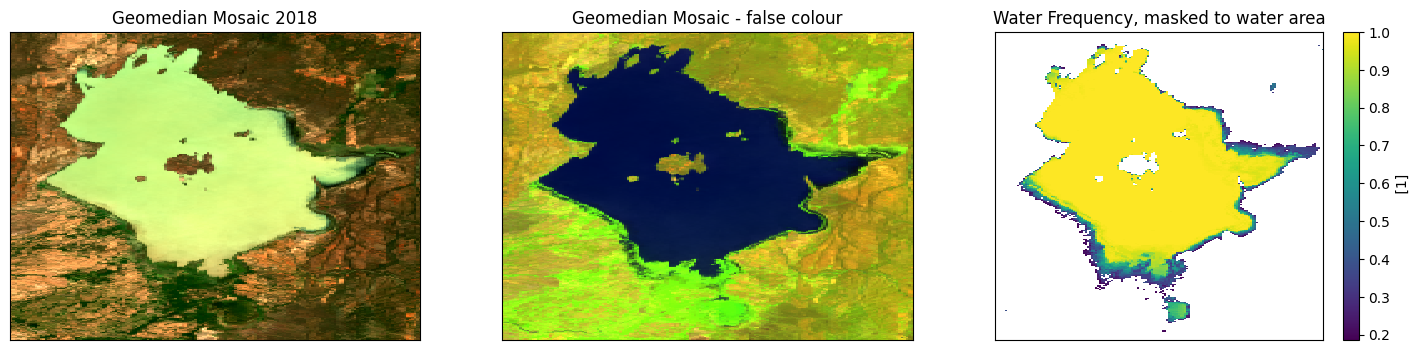

In [74]:
# --- visualise the area ---
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
#ds_annual.water_5yr.mean(dim='time').plot.imshow(ax=ax[2])
(ds.wofs_ann_wetcount.sum(dim='time')/ds.wofs_ann_clearcount.sum(dim='time')).where(ds.water_5yr.mean(dim='time')>0).plot.imshow(ax=ax[2])
#(ds_annual.wofs_ann_wetcount/ds_annual.wofs_ann_clearcount).where(ds_annual.water_5yr>0).mean(dim=('x','y')).plot.step(marker='',color='r',linestyle='-',ax=ax[2])

tindex = int(ds.time.size/2)
if ds.msi_agm[tindex]==True:
    rgb(ds,bands=['msi04_agm','msi03_agm','msi02_agm'],index=tindex,index_dim='time',ax=ax[0])
    rgb(ds,bands=['msi11_agm','msi8a_agm','msi02_agm'],index=tindex,index_dim='time',ax=ax[1])
else: 
    if ds.oli_agm[tindex]==True:
        rgb(ds,bands=['oli04_agm','oli03_agm','oli02_agm'],index=tindex,index_dim='time',ax=ax[0])
        rgb(ds,bands=['oli06_agm','oli05_agm','oli03_agm'],index=tindex,index_dim='time',ax=ax[1])
    else :
        if ds.tm_agm[tindex]==True:    
           rgb(ds,bands=['tm03_agm','tm02_agm','tm01_agm'],index=tindex,index_dim='time',ax=ax[0])
           rgb(ds,bands=['tm05_agm','tm04_agm','tm02_agm'],index=tindex,index_dim='time',ax=ax[1])
     
# Titles
ax[0].set_title("Geomedian Mosaic "+str(pd.DatetimeIndex(ds.time).year[tindex])), ax[0].xaxis.set_visible(False), ax[0].yaxis.set_visible(False)
ax[1].set_title("Geomedian Mosaic - false colour"), ax[1].xaxis.set_visible(False), ax[1].yaxis.set_visible(False)
ax[2].set_title("Water Frequency, masked to water area"), ax[2].xaxis.set_visible(False), ax[2].yaxis.set_visible(False);
#ax[2].set_title("Water extent mask"), ax[2].xaxis.set_visible(False), ax[2].yaxis.set_visible(False);
#ax[2].set_title("Average water frequency"), ax[2].xaxis.set_visible(True), ax[2].yaxis.set_visible(True);


### Calcuate FAI (floating algal index) and NDVI values:
#### - FAI and NDVI ar used to provide an measure of cyanopbacteria and floating vegetation, this is an important WQ measure.
#### - Pixels with significant NDVI and FAI values need to be excluded from other analyses
#### - Reporting on FAI / NDVI is also valuable. To do this, the 5-year wofs frequency is needed. This variale is called  "wofs_5yr_freq"


In [75]:
# --- run the FAI for annual geomedian based datasets and calculate the percent coverage --- 
#     Multiple fai values are produced, one for each instrument in the geomedian set. 
#     Values are standardised using mean values developed empirically, with MSI taken as the reference becasue there are more msi data. 
#     The FAI function needs to kmow the instrument because the bands used are instrunent-specific
#     Values are masked to a 5-year water mask specific to this purpose

ds = geomedian_FAI(ds,ds.water_5yr)

# --- calculate an annual percentage cover of high FAI
ds['fai_cover'] = \
        ('time'), \
        ((ds.agm_fai.count(dim=('x','y'))  / ds.water_5yr.count(dim=('x','y'))) \
         *100).round(2).data

# -- and save the percentage area affected in the results

annual_results = results['annual_results']
newcolname = 'fai_cover_percent'
if newcolname in annual_results.columns:  annual_results = annual_results.drop(labels=[newcolname],axis=1)
annual_results.insert(annual_results.columns.size,
                      newcolname,
                        ((ds.fai_cover))
                     )
results['annual_results'] = annual_results

In [76]:
# --- Calculate NDVI values for annual geomedians instrument ----
#     NDVI is calculated for each instrument in the series (tm, oli, msi).
#     The overall NDVI is a weighted mean (weighted by the number of observations in each geomedian)

ds = geomedian_NDVI(ds,ds.water_5yr)

ds['ndvi_cover'] = \
        ('time'), \
        ((ds.agm_ndvi.count(dim=('x','y'))  / ds.water_5yr.count(dim=('x','y'))) \
         *100).round(2).data

# -- and save the percentage area affected in the results

annual_results = results['annual_results']
newcolname = 'ndvi_cover_percent'
if newcolname in annual_results.columns:  annual_results = annual_results.drop(labels=[newcolname],axis=1)
annual_results.insert(annual_results.columns.size,
                      newcolname,
                        ((ds.ndvi_cover))
                     )
results['annual_results'] = annual_results


In [77]:
# --- a function to make nice step-plot data; we assume that we're working with time data and that the step intervals are even
def make_stepplot_data(tdata,ydata):
    delta = ((np.datetime64(tdata[1])- np.datetime64(tdata[0]))/2)
    steps = np.array([], dtype='datetime64')
    values = []
    for t in tdata:
        value  = ydata[tdata==t]
        tminus = t - delta
        tplus  = t + delta
        steps  = np.append(steps, [tminus,tplus])
        values = np.append(values,[value ,value])
    return(steps,values)    

In [78]:
# --- view the annual results ---
results['annual_results'].head()
print('Maxiumum observed FAI (%): ',results['annual_results'].fai_cover_percent.max())


Maxiumum observed FAI (%):  14.65


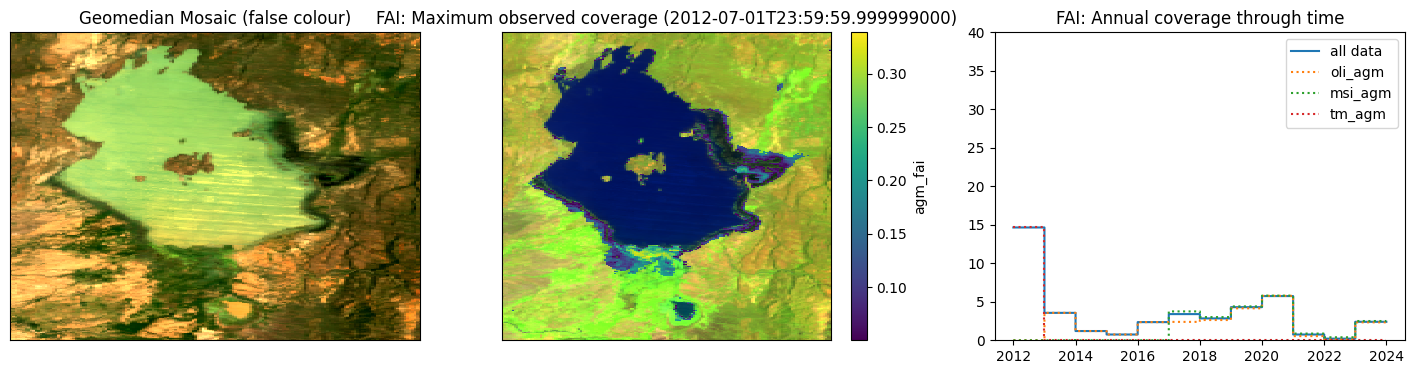

In [79]:
#--- visualise  the FAI annual results and image data
annual_results = results['annual_results']
max_year    = annual_results[annual_results.fai_cover_percent == annual_results.fai_cover_percent.max()].time.values[0]
max_year_index = list(annual_results.time).index(max_year)

fig, ax = plt.subplots(1, 3, figsize=(18, 4))

ax[2].set_ylim(0,40)

tindex = max_year_index
if ds.msi_agm[tindex]==True:
    rgb(ds,bands=['msi04_agm','msi03_agm','msi02_agm'],index=tindex,index_dim='time',ax=ax[0])
    rgb(ds,bands=['msi11_agm','msi8a_agm','msi03_agm'],index=tindex,index_dim='time',ax=ax[1])
else: 
    if ds.oli_agm[tindex]==True:
        print('trying oli')
        rgb(ds,bands=['oli04_agm','oli03_agm','oli02_agm'],index=tindex,index_dim='time',ax=ax[0])
        rgb(ds,bands=['oli06_agm','oli05_agm','oli03_agm'],index=tindex,index_dim='time',ax=ax[1])
    else :
        if ds.tm_agm[tindex]==True: 
           rgb(ds,bands=['tm03_agm','tm02_agm','tm01_agm'],index=tindex,index_dim='time',ax=ax[0])
           rgb(ds,bands=['tm05_agm','tm04_agm','tm02_agm'],index=tindex,index_dim='time',ax=ax[1])

ds.sel(time=str(max_year)).agm_fai.plot(ax=ax[1])

t,y = make_stepplot_data(annual_results.time,annual_results.fai_cover_percent)
plt.plot(t,y,label='all data')

for instrument in 'oli_agm','msi_agm','tm_agm':
    if instrument in ds.data_vars:
        y   = (((ds[instrument+'_fai'].count(dim=('x','y')) * parameters['cell_area']) / annual_results.area_km2) * 100).round(2)
        t,y = make_stepplot_data(np.asarray(ds.time),y)
        plt.plot(t,y,linestyle=':',label=instrument)

# Titles
ax[0].set_title("Geomedian Mosaic (false colour)"), ax[0].xaxis.set_visible(False), ax[0].yaxis.set_visible(False)
ax[1].set_title("FAI: Maximum observed coverage ("+str(max_year)+")"), ax[1].xaxis.set_visible(False), ax[1].yaxis.set_visible(False);
ax[2].set_title("FAI: Annual coverage through time"), ax[2].xaxis.set_visible(True), ax[2].yaxis.set_visible(True);
plt.legend()
plt.show()

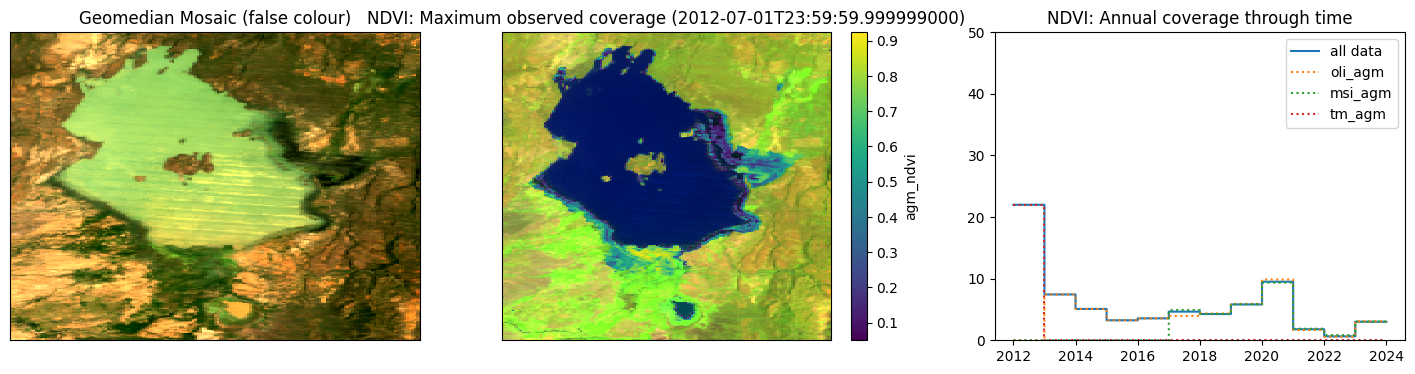

In [80]:
#--- visualise  the NDVI annual results and image data
annual_results = results['annual_results']
max_year    = annual_results[annual_results.ndvi_cover_percent == annual_results.ndvi_cover_percent.max()].time.values[0]
max_year_index = list(annual_results.time).index(max_year)

fig, ax = plt.subplots(1, 3, figsize=(18, 4))

ax[2].set_ylim(0,50)

tindex = max_year_index
if ds.msi_agm[tindex]==True:
    rgb(ds,bands=['msi04_agm','msi03_agm','msi02_agm'],index=tindex,index_dim='time',ax=ax[0])
    rgb(ds,bands=['msi11_agm','msi8a_agm','msi02_agm'],index=tindex,index_dim='time',ax=ax[1])
else: 
    if ds.oli_agm[tindex]==True:
        rgb(ds,bands=['oli04_agm','oli03_agm','oli02_agm'],index=tindex,index_dim='time',ax=ax[0])
        rgb(ds,bands=['oli06_agm','oli05_agm','oli03_agm'],index=tindex,index_dim='time',ax=ax[1])
    else :
        if ds.tm_agm[tindex]==True: 
           rgb(ds,bands=['tm03_agm','tm02_agm','tm01_agm'],index=tindex,index_dim='time',ax=ax[0])
           rgb(ds,bands=['tm05_agm','tm04_agm','tm02_agm'],index=tindex,index_dim='time',ax=ax[1])

ds.sel(time=str(max_year)).agm_ndvi.plot(ax=ax[1])

t,y = make_stepplot_data(annual_results.time,annual_results.ndvi_cover_percent)
plt.plot(t,y,label='all data')

for instrument in 'oli_agm','msi_agm','tm_agm':
    if instrument in ds.data_vars:
        y   = (((ds[instrument+'_ndvi'].count(dim=('x','y')) * parameters['cell_area']) / annual_results.area_km2) * 100).round(2)
        t,y = make_stepplot_data(np.asarray(ds.time),y)
        plt.plot(t,y,linestyle=':',label=instrument)

# Titles
ax[0].set_title("Geomedian Mosaic (false colour)"), ax[0].xaxis.set_visible(False), ax[0].yaxis.set_visible(False)
ax[1].set_title("NDVI: Maximum observed coverage ("+str(max_year)+")"), ax[1].xaxis.set_visible(False), ax[1].yaxis.set_visible(False);
ax[2].set_title("NDVI: Annual coverage through time"), ax[2].xaxis.set_visible(True), ax[2].yaxis.set_visible(True);
plt.legend()
plt.show()

In [81]:
# --- Introduce a 'clearwater' boolean mask for areas of water that don't have significant fai values#     ? should we also test for high NDVI? 
# adding an additional requirement that the area should  be water this year also
def set_clearwater(ds):
    #ds['clearwater'] = xr.where(np.isnan(ds.agm_fai),xr.where(ds.water_5yr==1,True,False),False)
    ds['clearwater'] = np.logical_and(np.isnan(ds['agm_fai']),ds['water_5yr']==1)
    ds['clearwater'] = np.logical_and(ds['clearwater'] , ds['wofs_ann_water'])
    return(ds)
ds=set_clearwater(ds)

#ds.where(ds.clearwater).isel(time=17).oli03_agm.plot()

### Pixel corrections

In [84]:
# manual intervention - reserve a version before the dark pixel corrections
# 
first_time = True
if first_time:
    ds0 = ds
    first_time = False

In [85]:
# Apply a dark-pixel correction; optionally (and nominally) dropping the originals

ds = apply_R_correction(ds0,['msi_agm','oli_agm','tm_agm'],
                   water_mask=ds.water_5yr,
                   drop = True,
                   test = False,verbose=False)
#rgb(apply_R_correction(ds,['msi_agm','oli_agm','tm_agm'],water_mask=ds.clearwater),bands=['msi04_agmr','msi03_agmr','msi02_agmr'],robust=True,index=24,index_dim='time')

---variable -->   oli01_agm   <-- anticipated but not found in the dataset (non-fatal)
---variable -->   msi01_agm   <-- anticipated but not found in the dataset (non-fatal)


### Hue; calculation of the hue value 

In [86]:
ds = geomedian_hue(ds,ds.clearwater==True,test=True,verbose=True)


 Aborting hue calculation for instrument  oli  due to lack of necessary data bands



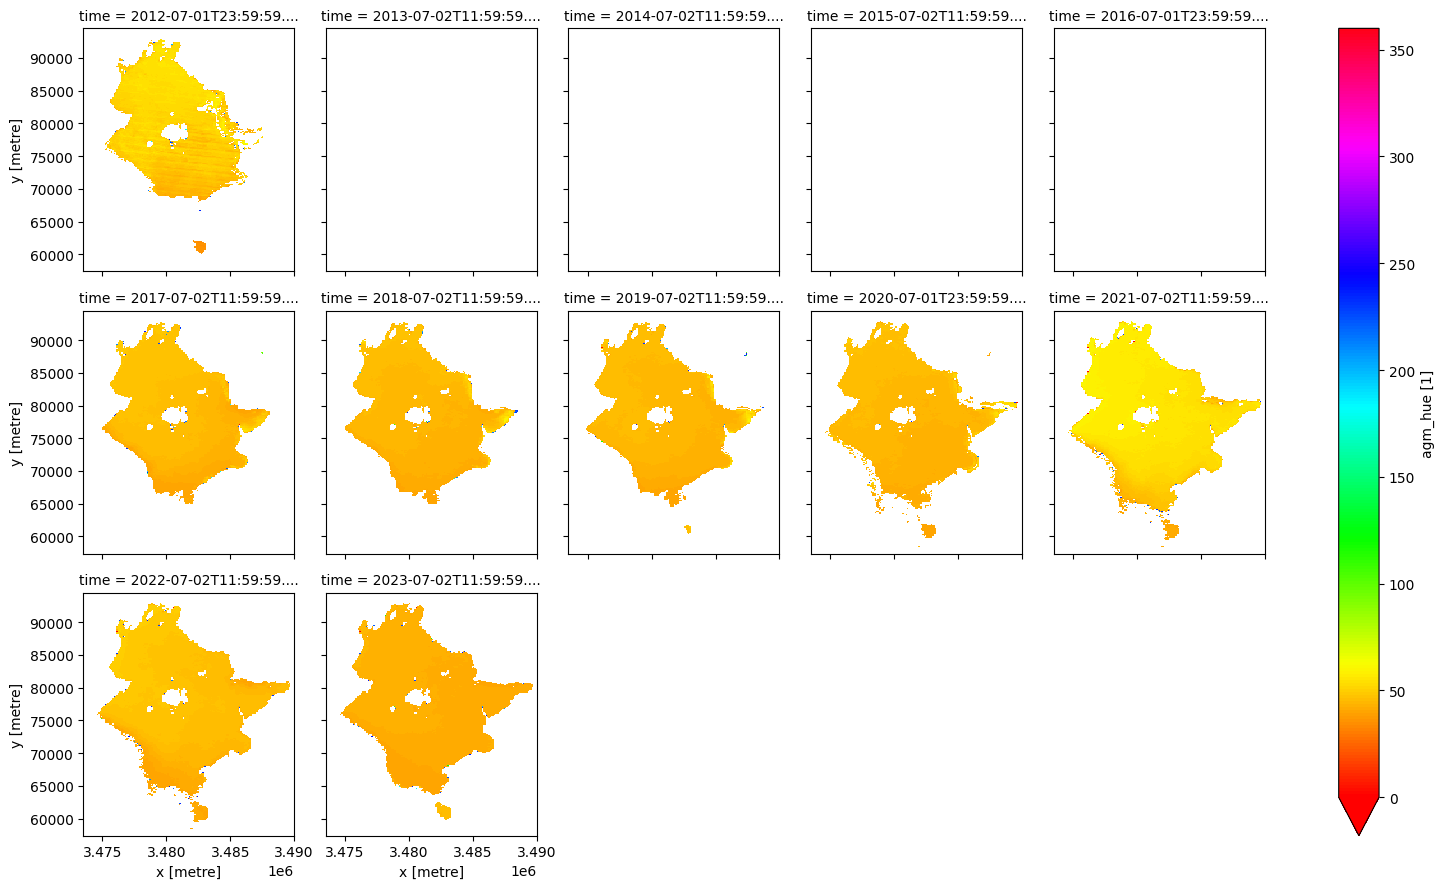

In [87]:
# --- visualise results ---
img = ds.agm_hue.plot.imshow(
                robust=False,
                col='time',
                col_wrap=5,cmap='hsv',vmin=0,vmax=360)


### Optical Water Type (OWT)
The algorithm compares each pixel's band values with 13 reference spectra based on the spectral angle. Therefore, for each pixel 13 dot products are calculated. 
Memory intensive, data are down-sampled for processing. 
Methods as per Spyrakos et al 2018

OWT is estimated from the spectral angle between the pixel and the refence spectra for each of the 13 OWTs
- extension to other sensors (TM, OLCI) also quite straightforward but the OWT refence data would need to be brought in.

we can do this for Landsat and for Sentinel, however in the geomedian 
- OLI has only 3 available bands (2,3,4) - missing band 1
- MSI has only 6  of 7 useful bands (missing band 1) 
- TM  has 4  (all of 1,2,3,4), but the TM geomedians are not provided after 2012 :(

**To do, ideally : Upload the full reference spectra and establish an import function to bring in as a data array.**
- Here, I have estimated the mean band reflectance for each sensor in excell using the spectral response curves (MSI response functions are available on-line) and used the results directly 

#### Zhang et al. group the OWTs as follows:
- oligotrophic (clear)           : 3, 9, 13           (apply NASA OCx model for ChlA) - we don't see much of this!!!
- eutopic and bluegreen waters   : 1, 2, 4, 5, 11, 12 (apply two band models of Gurlin et al for ChlA)
- hypereutrophic and green-brown : 6, 7, 8, 10        (apply TC2 alg for ChlA)   

#### Run the process: 
- read in the spectral curves for each optial water type, and model the response vectors for each sensor and band
- compare the observed pixel values with the prediction, for each OWT
- select the closest OWT

In [88]:
#%run _WQ_functions.py
ds = run_OWT(ds,agm=True)
# --- take the owt with the best observations 
ds['agm_owt'] = xr.where(ds.msi_agm,ds.msi_agm_owt,
                         xr.where(ds.oli_agm,ds.oli_agm_owt,
                                  xr.where(ds.tm_agm,ds.tm_agm_owt,np.nan)))


In [89]:
ds

<xarray.Dataset> Size: 264MB
Dimensions:              (time: 12, y: 371, x: 165)
Coordinates:
  * time                 (time) datetime64[ns] 96B 2012-07-01T23:59:59.999999...
  * y                    (y) float64 3kB 9.445e+04 9.435e+04 ... 5.745e+04
  * x                    (x) float64 1kB 3.474e+06 3.474e+06 ... 3.49e+06
    spatial_ref          int32 4B 6933
Data variables: (12/69)
    oli05_agm            (time, y, x) float64 6MB nan nan ... 1.6e+03 1.51e+03
    oli06_agm            (time, y, x) float64 6MB nan nan ... 1.556e+03
    oli07_agm            (time, y, x) float64 6MB nan nan ... 1.164e+03
    oli_agm_smad         (time, y, x) float32 3MB nan nan ... 0.003092 0.002673
    oli_agm_emad         (time, y, x) float32 3MB nan nan nan ... 257.9 224.8
    oli_agm_bcmad        (time, y, x) float32 3MB nan nan ... 0.04226 0.03645
    ...                   ...
    msi_agm_hue          (time, y, x) float64 6MB nan nan nan ... 40.11 40.11
    tm_agm_hue           (time, y, x) float64 6MB 46.96 46.23 46.7 ... nan nan
    msi_agm_owt          (time, y, x) float32 3MB nan nan nan ... nan nan nan
    oli_agm_owt          (time, y, x) float64 6MB nan nan nan ... nan nan nan
    tm_agm_owt           (time, y, x) float32 3MB nan nan nan ... nan nan nan
    agm_owt              (time, y, x) float64 6MB nan nan nan ... nan nan nan
Attributes:
    crs:           EPSG:6933
    grid_mapping:  spatial_ref

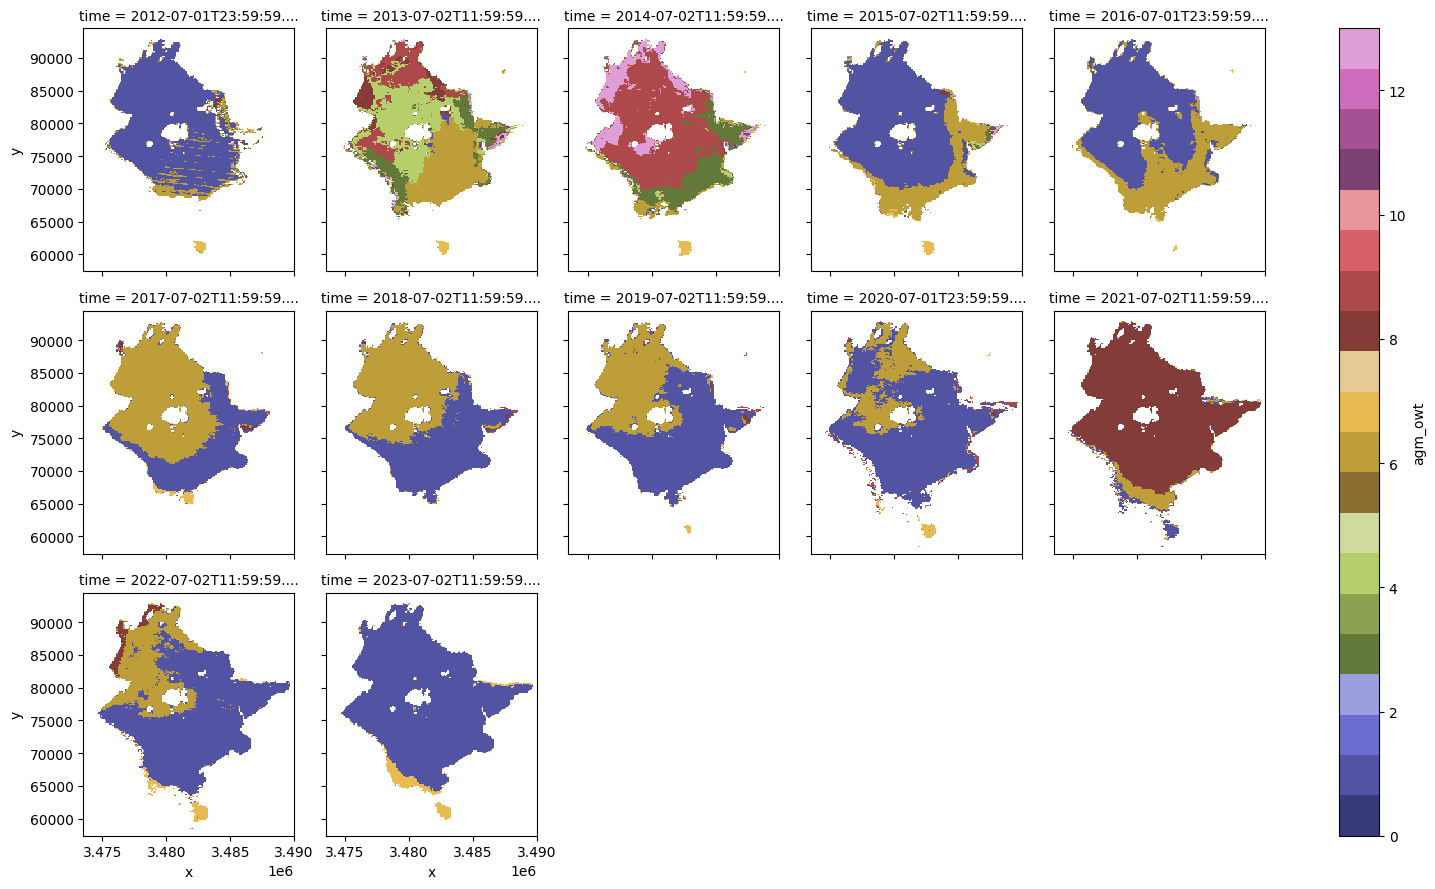

In [90]:
# --- visualise results ---
img = ds.agm_owt.plot.imshow(
                robust=False,
                col='time',
                col_wrap=5,vmin=0,vmax=13, cmap = 'tab20b')


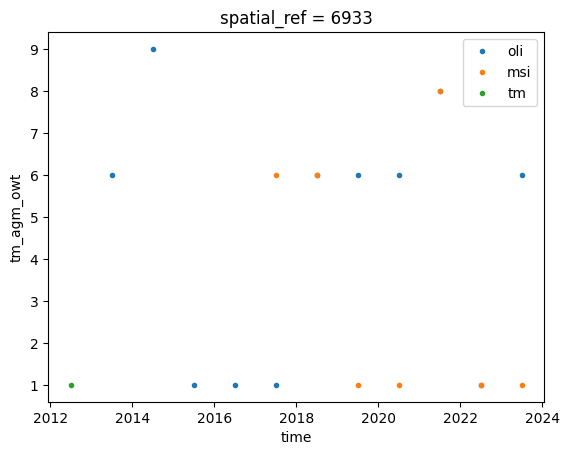

In [91]:
# visualise the variations in OWT with instrument 
ds.oli_agm_owt.median(dim=('x','y')).plot(linestyle='',marker='.',label='oli')
ds.msi_agm_owt.median(dim=('x','y')).plot(linestyle='',marker='.',label='msi')
ds.tm_agm_owt.median(dim=('x','y')).plot(linestyle='',marker='.',label='tm')
plt.legend()
plt.show()

In [92]:
# --- drop excess material ---
ds = ds.drop_vars(['oli_agm_owt','msi_agm_owt','tm_agm_owt'],errors='ignore')

### Calculate the raw water quality measurements and indices
- A dictionary is used to manage water quality algorithms and the bands that are used in them. This retains flexibility (e.g. algorithms can be run with multiple sensors) and avoids errors
- NEW DIMENSIONS are added to the dataset to house the results. One dimension is added called 'chla', and one called 'tss'. This appraoch simplifies later processing when we want to pool the measures as an ensemble. (For simplicity, I may remove this and bring in at a later stage..)

##### A small problem 
- the time-only variables get expanded to time,y,x. Ugly.


In [93]:
# --- set the dictionary of algorithms to apply --- 
algorithms_chla,algorithms_tsm = set_wq_algorithms(suffix='_agm')

In [94]:
# ---- Apply the WQ algorithms to water areas, adding variables to the dataset and building  a list of water quality variable nanmes
# -- this can be run either keeping the wq variables as separate variables on the dataset, or by moving them into new dimensions, 'tss' and 'chla'
# -- If the arguments 'new_dimension_name' or 'new_varname' are None (or empty), then the outputs will be retained as separate variables in a 3d dataset

# For simplicity, set a 'clearwater' array as a mask for processing the water quality variables:


if True: #put the data into a new dimension, call the variable 'tss' or 'chla'
    ds,tsm_vlist  = WQ_vars(ds.where(ds.clearwater),
                        algorithms_tsm,  
                        instruments, 
                        new_dimension_name='tss_measure', 
                        new_varname='tss', 
                        verbose=False)
    ds,chla_vlist = WQ_vars(ds.where(ds.clearwater),
                        algorithms_chla, 
                        instruments, 
                        new_dimension_name='chla_measure', 
                        new_varname='chla',
                        verbose=False)

else:  #keep it simple, just add new data as new variables in a 3-D dataset 
    ds,tsm_vlist  = WQ_vars(ds.where(ds.clearwater),
                        algorithms_tsm,  
                        instruments, 
                        new_dimension_name=None, 
                        new_varname=None, 
                        verbose=verbose)
    ds,chla_vlist = WQ_vars(ds.where(ds.clearwater),
                        algorithms_chla, 
                        instruments, 
                        new_dimension_name=None, 
                        new_varname=None,
                        verbose=verbose)
wq_varlist = np.append(tsm_vlist,chla_vlist)


### Tidy up - drop temp variables 


In [95]:
# ---- tidy up by dropping excess variables ---
keeplist = ('wofs_ann_clearcount','wofs_ann_wetcount','wofs_ann_freq','wofs_ann_freq_sigma','wofs_pw_threshold','wofs_ann_pwater','watermask','owt_msi','tss','chla')
#the keeplist is not complete; if the wq variables are retained as variables they will appear in a listing of data_vars. 
#therefore, revert to the instruments dictionary to list variables to drop
droplist = []
for instrument in list(instruments.keys()):
    for band in list(instruments[instrument].keys()):
        variable = instruments[instrument][band]['varname']
        if not (variable in keeplist): 
            droplist=np.append(droplist,variable)
            droplist=np.append(droplist,variable+'r')
for varname in droplist:
    if varname in ds.data_vars:
        ds = ds.drop_vars(varname)
    

## Harmonisation 
### (Apply the corrections developed in WP2.2)


#### Read in the key data files:


In [96]:
# --- the lookup table links each measurement to a reference measurement
lookup = pd.read_csv(data_directory+lookup_table_filename,index_col=0)

# --- the distributions data has the statistical distributions of all variables, calculated on all images (not geomedians) for 2019 and 2020 over about 20 sites.
#distributions =  xr.open_dataset(data_directory+distributions_filename).load(); distributions.close()
distributions =  pd.read_csv(data_directory+distributions_filename, index_col=0)

# --- normalisation parameters are simple offset and scale parameters
#     read these first into a DataFrame and then convert to a DataSet

np_data = pd.read_csv(data_directory+np_parameters_filename)

In [97]:
distributions=distributions.to_xarray()

#### Harmonisation for instrument

In [98]:
# loop through tss and chla data arrays withing the dataset...
# loop through the variables in each case... 
# assign values  back into the dataset
for mmt in 'tss','chla':
    vartype = mmt+'_measure'
    for varname in list(ds[vartype].values):
        ds[mmt].loc[{vartype :[varname]}]= \
            harmonise_for_instrument(
                ds[mmt].loc[{vartype :[varname]}],
                varname,
                lookup,
                distributions,
                test=False)


#### Add normalisation (scale and offset) to the dataset

In [99]:
# Add the normalisation paramters to the dataset

ds['tss_scale']       = ('tss_measure'),np_data[np_data['var']=='tss']['scale'].values
ds['tss_offset']      = ('tss_measure'),np_data[np_data['var']=='tss']['offset'].values
ds['tss_era_factor']  = ('tss_measure'),np_data[np_data['var']=='tss']['era_factor'].values

ds['chla_scale']      = ('chla_measure'),np_data[np_data['var']=='chla']['scale'].values
ds['chla_offset']     = ('chla_measure'),np_data[np_data['var']=='chla']['offset'].values
ds['chla_era_factor'] = ('chla_measure'),np_data[np_data['var']=='chla']['era_factor'].values
    

#### Apply the parameters to produce harmonised data

In [100]:
for var in ['tss','chla']:
    ds[var+'_h'] = \
    (((ds[var] \
     * ds[var+'_scale']) \
     + ds[var+'_offset']) \
     * ds[var+'_era_factor'])


NameError: name 'Q' is not defined

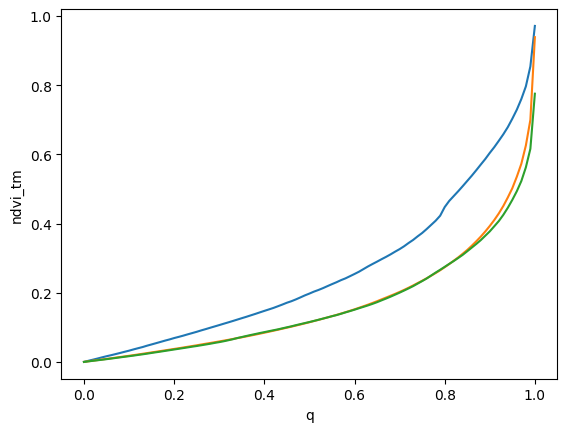

In [101]:
distributions.ndvi_oli.plot()
distributions.ndvi_msi.plot()
distributions.ndvi_tm.plot()
ds.oli_agm_ndvi.quantile(Q,dim=('x','y','time')).plot(label='oli_agm')
ds.msi_agm_ndvi.quantile(Q,dim=('x','y','time')).plot(label='msi_agm')
ds.tm_agm_ndvi.quantile(Q,dim=('x','y','time')).plot(label='tm_agm')
plt.legend(loc='upper left')
plt.show()


## Results - fai, ndvi, hue

In [ ]:
# make a list of variables to be processed:
vlist = {}
for variable in ['ndvi']:
    for instrument in ['tm','oli','msi']:
        in_name  = instrument+'_agm_'+variable
        out_name = variable+'_'+instrument+'_h'
        vlist[in_name] = out_name

print('\n\n\n----------------------------------------\n Results for '+variable+'\n------------------------------------')
for variable in vlist.keys():
    for var in variable,vlist[variable] :
        ds[var].median(dim=('x','y')).plot(label = var)
    plt.ylim(0,.5)
ds[variable[variable.find('agm_'):]].median(dim=('x','y')).plot(label = variable[variable.find('agm_'):])
plt.title(variable+' before and after harmonisation')
plt.legend()    
plt.show()
        

In [ ]:
ds.tm_agm_ndvi.mean(dim=('x','y')).plot()

In [102]:
lookup

,target,reference
0,ndci_msi54,ndci_msi74
1,ndci_msi64,ndci_msi74
2,ndci_msi74,ndci_msi74
3,ndci_tm43,ndci_msi74
4,ndci_oli54,ndci_msi74
5,chla_toming_msi,chla_toming_msi
6,chla_3bda_msi,chla_3bda_msi
7,chla_3bda_oli,chla_3bda_msi
8,chla_3bda_tm,chla_3bda_msi
9,chla_tebbs_msi,chla_tebbs_msi


In [103]:
for instrument in ['oli'] :
    varname = 'hue'+'_'+instrument
    print('\n\n\n----------------------------------------\n Results for '+varname+'\n------------------------------------')
    for var in [varname,varname+'_h'] :
        ds[var] .median(dim=(varname+'_measure')).median(dim=('x','y')).plot(label = var)
    plt.title(varname+' before and after harmonisation')
    plt.legend()    
    plt.show()


    for Q in [0.2,0.5,0.8] :
        if Q != 0.5: ls = ':' 
        else       :ls = '-'

        ds[varname+'_h'].median(dim=(varname+'_measure')).quantile(Q,dim=('x','y')).plot(label = str(Q)+' quantile',linestyle = ls)
    plt.title('Variability within the waterbody - '+varname)
    plt.legend()
    plt.show()

    for Q in [0.2,0.5,0.8] :
        if Q != 0.5: ls = ':' 
        else       :ls = '-'

        ds[varname+'_h'].median(dim=('x','y')).quantile(Q,dim=(varname+'_measure')).plot(label = str(Q)+' quantile',linestyle = ls)
    plt.title('Variability between measurements - '+varname)
    plt.legend()
    plt.show()

    Q = np.arange(0,1,0.1)
    ds[varname+'_h'] \
       .median(dim=(varname+'_measure')).quantile(Q,dim=('x','y')).plot()   
    plt.title('Variability within the waterbody -'+varname)
    plt.legend()
    plt.show()


    Q = np.arange(0,1,0.1)
    ds[varname+'_h'] \
        .median(dim=(varname+'_measure')).quantile(0.5,dim=('time')).plot()   
    plt.title('Spatial pattern of '+varname)
    plt.legend()
    plt.show()

    if varname in ['tss','chla']:
        for measure in ds[varname+'_measure'] :
            Q = np.arange(0,1,0.1)
            ds[varname+'_h'] \
                .loc[{varname+'_measure' : measure}] \
                .quantile(Q,dim=('time','x','y')).plot(label=measure.item(),linestyle=':')   
        plt.title('Distributions of '+varname)
        #plt.legend(loc='upper left')
        plt.show()




----------------------------------------
 Results for hue_oli
------------------------------------


KeyError: "No variable named 'hue_oli'. Variables on the dataset include ['wofs_ann_freq', 'wofs_ann_clearcount', 'wofs_ann_wetcount', 'wofs_ann_freq_sigma', 'wofs_ann_confidence', ..., 'chla_scale', 'chla_offset', 'chla_era_factor', 'tss_h', 'chla_h']"

## Results - tss and chla

### .... Over the full time series




----------------------------------------
 Results for tss
------------------------------------


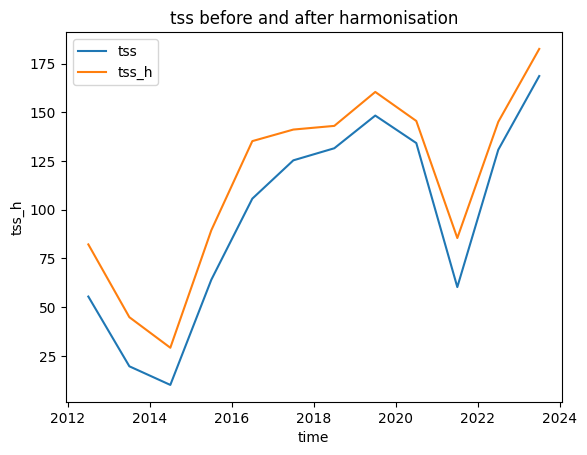

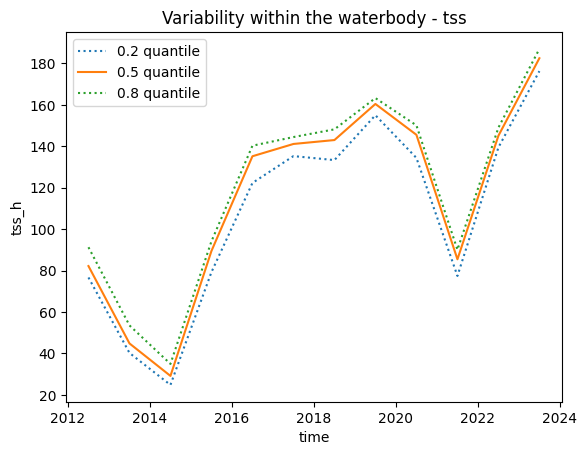

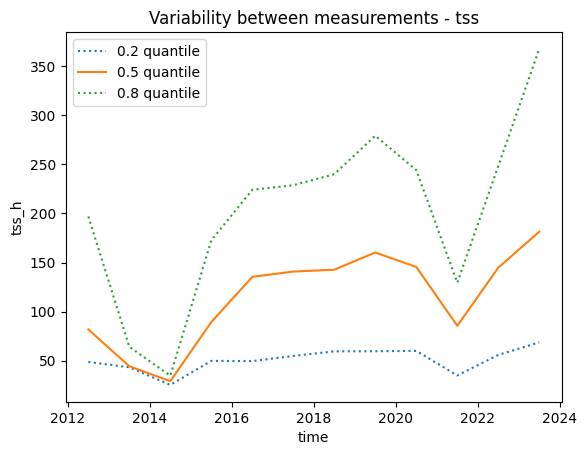

/tmp/ipykernel_2063/562364581.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


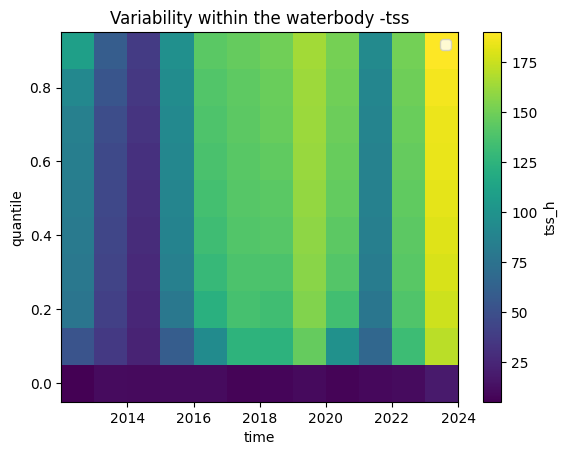

/tmp/ipykernel_2063/562364581.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


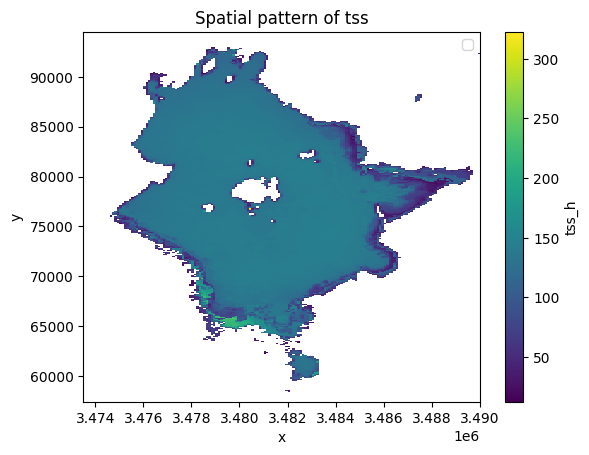

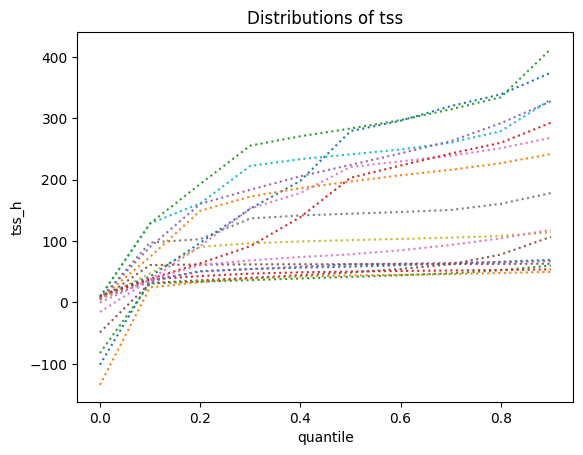




----------------------------------------
 Results for chla
------------------------------------


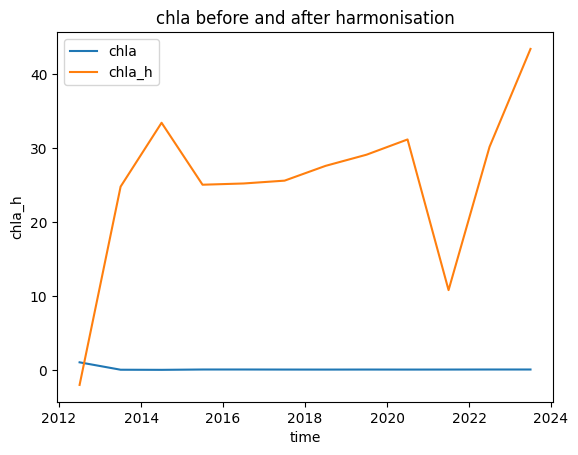

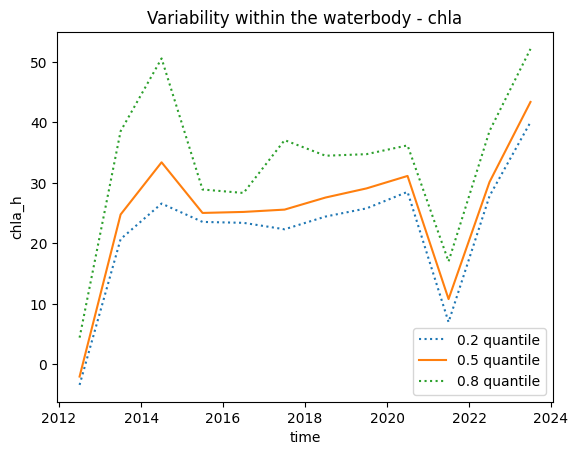

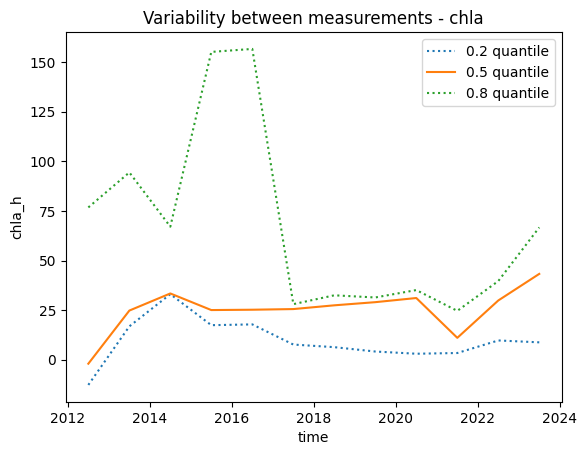

/tmp/ipykernel_2063/562364581.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


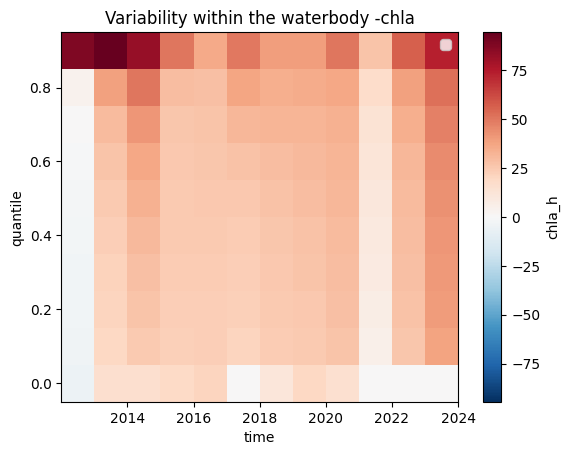

/tmp/ipykernel_2063/562364581.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


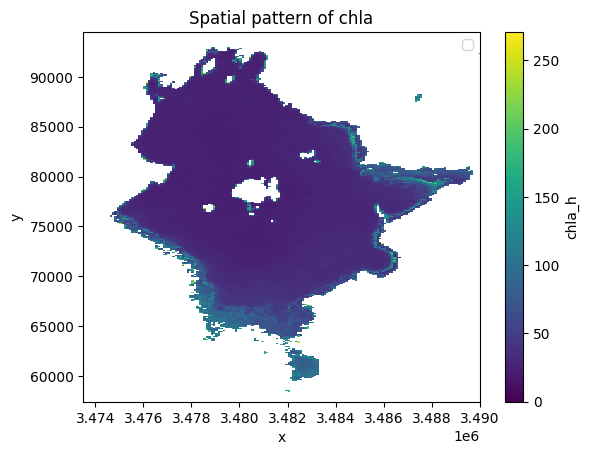

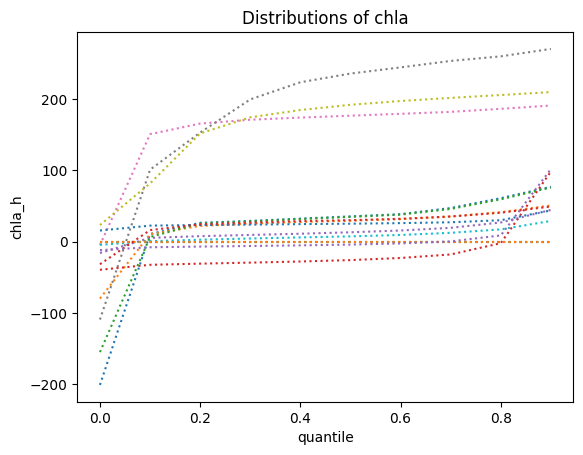

In [104]:
#### Results through time for tss and chla
for varname in ['tss','chla'] :
    print('\n\n\n----------------------------------------\n Results for '+varname+'\n------------------------------------')
    for var in [varname,varname+'_h'] :
        ds[var] .median(dim=(varname+'_measure')).median(dim=('x','y')).plot(label = var)
    plt.title(varname+' before and after harmonisation')
    plt.legend()    
    plt.show()


    for Q in [0.2,0.5,0.8] :
        if Q != 0.5: ls = ':' 
        else       :ls = '-'

        ds[varname+'_h'].median(dim=(varname+'_measure')).quantile(Q,dim=('x','y')).plot(label = str(Q)+' quantile',linestyle = ls)
    plt.title('Variability within the waterbody - '+varname)
    plt.legend()
    plt.show()

    for Q in [0.2,0.5,0.8] :
        if Q != 0.5: ls = ':' 
        else       :ls = '-'

        ds[varname+'_h'].median(dim=('x','y')).quantile(Q,dim=(varname+'_measure')).plot(label = str(Q)+' quantile',linestyle = ls)
    plt.title('Variability between measurements - '+varname)
    plt.legend()
    plt.show()

    Q = np.arange(0,1,0.1)
    ds[varname+'_h'] \
       .median(dim=(varname+'_measure')).quantile(Q,dim=('x','y')).plot()   
    plt.title('Variability within the waterbody -'+varname)
    plt.legend()
    plt.show()


    Q = np.arange(0,1,0.1)
    ds[varname+'_h'] \
        .median(dim=(varname+'_measure')).quantile(0.5,dim=('time')).plot()   
    plt.title('Spatial pattern of '+varname)
    plt.legend()
    plt.show()

    if varname in ['tss','chla']:
        for measure in ds[varname+'_measure'] :
            Q = np.arange(0,1,0.1)
            ds[varname+'_h'] \
                .loc[{varname+'_measure' : measure}] \
                .quantile(Q,dim=('time','x','y')).plot(label=measure.item(),linestyle=':')   
        plt.title('Distributions of '+varname)
        #plt.legend(loc='upper left')
        plt.show()



    


### ... Spatial patterns through time :

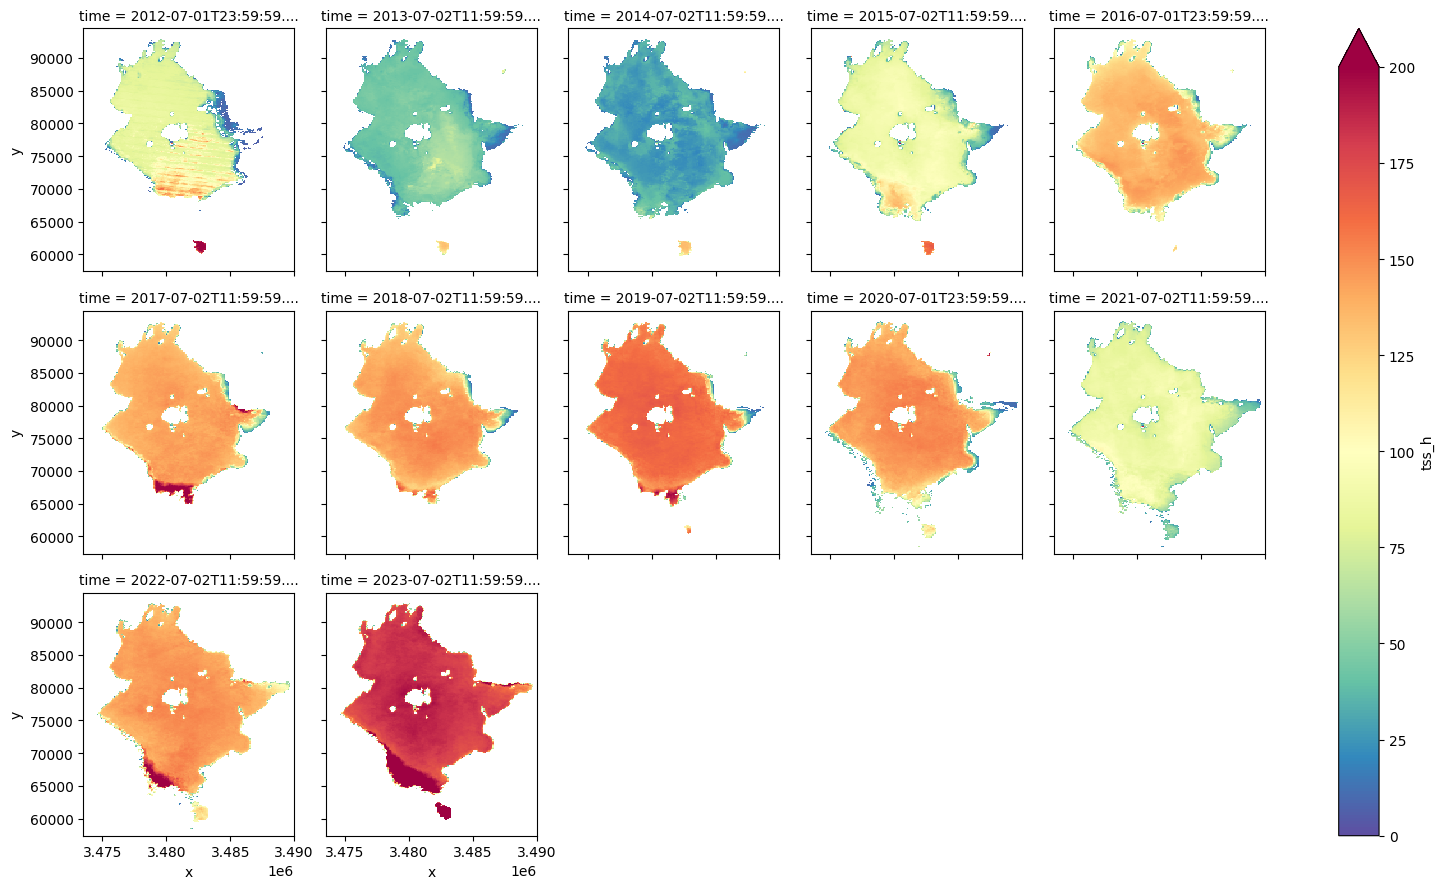

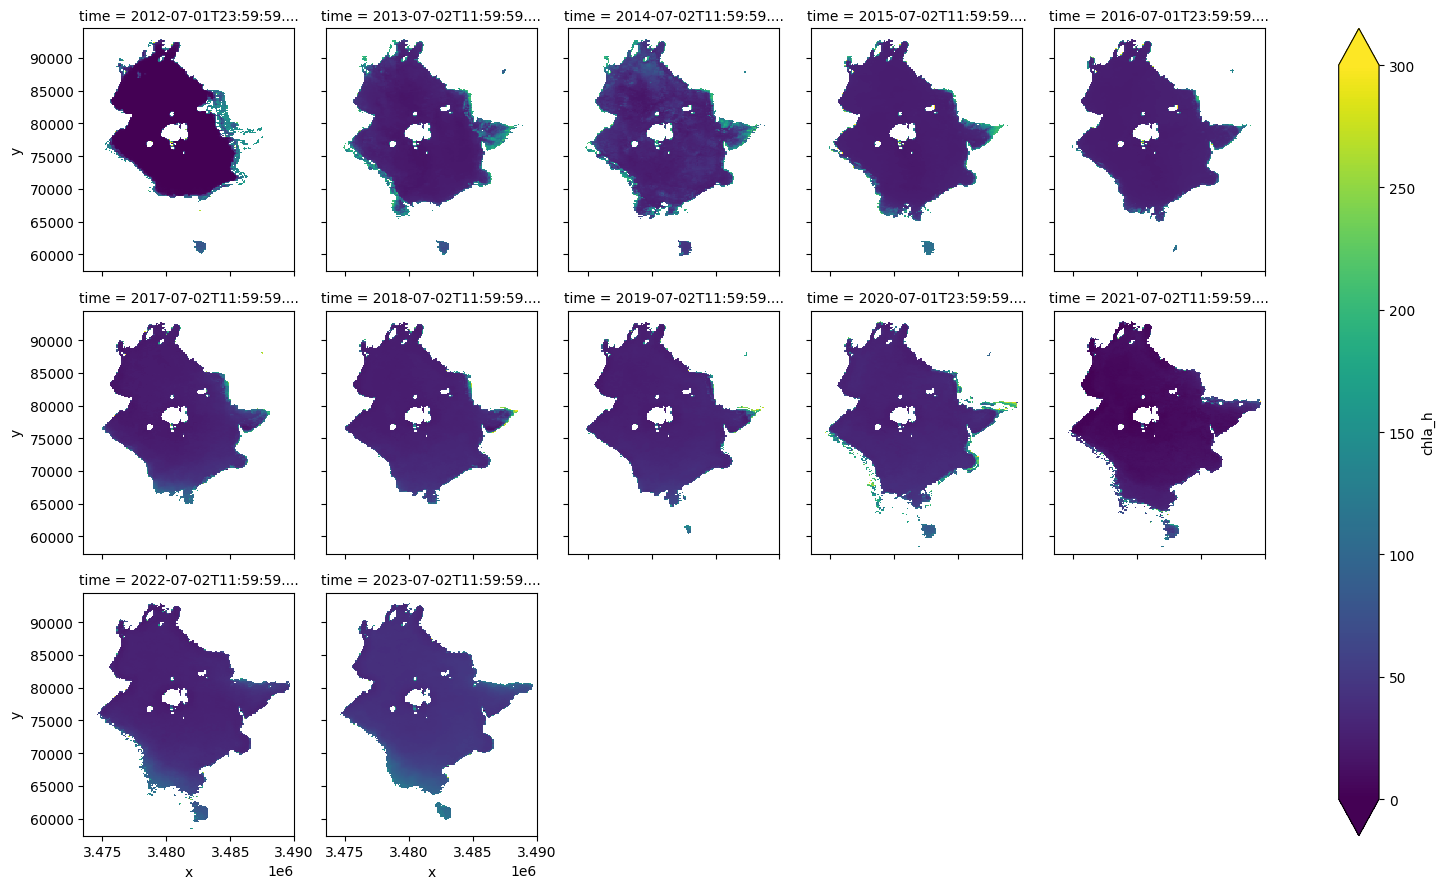

In [105]:
# tss and chla through time
img = (ds.tss_h).median(dim=('tss_measure')).plot.imshow(vmin=0,vmax=200,robust=False,col='time',col_wrap=5,cmap='Spectral_r')
img = (ds.chla_h).median(dim=('chla_measure')).plot.imshow(vmin=0,vmax=300,robust=False,col='time',col_wrap=5)


### Calculate the trophic state from the ChlA values
- this serves mainly to demonstrate the function.
- changes to this will be in the preparation of the chla values


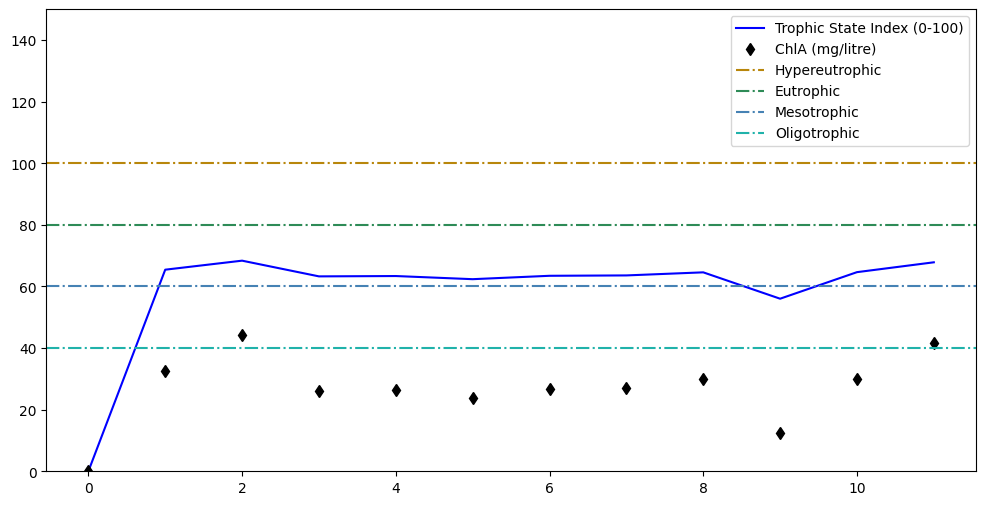

In [106]:
## plot the Trophic state
df = pd.DataFrame(
    data = [
           [100,'Hypereutrophic','darkgoldenrod'],
           [80,'Eutrophic','seagreen'],
           [60,'Mesotrophic','steelblue'],
           [40,'Oligotrophic','lightseagreen'],
    ],
    columns = ['TSI','desc','colour']
)

fig, ax = plt.subplots(figsize=(12, 6))

x = ds.time
y = trophic_state((ds.chla_h).median(dim=('chla_measure','x','y')))
z =              ((ds.chla_h).median(dim=('chla_measure','x','y')))

ax.plot(y, color='blue', label='Trophic State Index (0-100)',linestyle='-')
ax.plot(z, color='black', label='ChlA (mg/litre)',linestyle='',marker='d')

for y in df.TSI:
    label  = df[df.TSI==y]['desc'].item()
    colour = df[df.TSI==y]['colour'].item()
    plt.axhline(y,label = label,linestyle ='-.',color=colour)


plt.ylim([0, 150])
plt.legend(loc='best')
plt.show()


### Adjust variables hue, fai, and ndvi 
- some name changes are needed for consistency with the lookup table
#### This shows how, in theory, 
#### In Practice, these changes would need to be implemented before calculating the agm_hue, fai and ndvi values

- the values in the dataset at this point are already modified by a scale factor, THEREFORE
- changes to the 'geomedian_fai' and 'geomedian_ndvi' functions are required before this can be done
- improvements are to be expected but may not be significant; testing results is desirable
- the current approach lacks some transparency, so implementing these changes is a good idea in general.
#### SO
- this change may need to wait a few days...



In [108]:
# make a list of variables to be processed and deal with naming issues:
vlist = {}
for variable in 'fai','ndvi','hue':
    for instrument in 'tm','oli','msi':
        in_name  = instrument+'_agm_'+variable
        out_name = variable+'_'+instrument
        vlist[in_name] = out_name

In [109]:
# run through the harmonisation process, save as a new variable 
over_write = False
if over_write : suffix = ''
else          : suffix = '_h' 
for a in vlist.keys():
    a = [a,vlist[a]]
    if a[0] in ds.data_vars:
        print('... processing '+a[0]+' to produce '+a[1]+suffix )
        ds[a[1]+suffix] = \
        harmonise_for_instrument(
                ds.rename_vars({a[0]:a[1]})[a[1]],
                a[1],
                lookup,
                distributions,
                test=False)#.mean(dim='time').plot(vmin=20,vmax=100,cmap='rainbow')

    else : print('variable nor in dataset --> '+a[0])

... processing tm_agm_fai to produce fai_tm_h
... processing oli_agm_fai to produce fai_oli_h
... processing msi_agm_fai to produce fai_msi_h
... processing tm_agm_ndvi to produce ndvi_tm_h
... processing oli_agm_ndvi to produce ndvi_oli_h
... processing msi_agm_ndvi to produce ndvi_msi_h
... processing tm_agm_hue to produce hue_tm_h
... processing oli_agm_hue to produce hue_oli_h
... processing msi_agm_hue to produce hue_msi_h


## Job done. 

### Saving the summary stats for this area - picked up in WP2.2
- save the results in a dataset with 5 dimensions :  place, time, tss_measure, chla_measure and quantile.
- this dataset will relate to only one place; progressively adding.
- 

#### Save results to a local directory for re-use

In [110]:
# --- calculate summary statistics 
#---------------------------------------------------------
q_values     = np.arange(0,1.01,0.01)
tss_results  = ds.tss.quantile(q_values,dim=('x','y'))
chla_results = ds.chla.quantile(q_values,dim=('x','y'))

wq_results = xr.Dataset(
    data_vars =   None,
    coords     = {
                  'time': ds.time,
                  'place' : [placename],
                  'tss_measure' : ds.tss_measure,
                  'chla_measure': ds.chla_measure,
                  'quantile'    : q_values
                 },
    )

wq_results['tss']  = tss_results.expand_dims('place')
wq_results['chla'] = chla_results.expand_dims('place')

# ---- write to a file --- 
directory = './'
allresultsfilename = 'wq_raw'
filename = allresultsfilename+'_'+placename+'.nc'
wq_results.to_netcdf(directory+filename)



In [111]:
wq_results

<xarray.Dataset> Size: 313kB
Dimensions:       (time: 12, tss_measure: 17, chla_measure: 15, place: 1,
                   quantile: 101)
Coordinates:
  * time          (time) datetime64[ns] 96B 2012-07-01T23:59:59.999999 ... 20...
  * tss_measure   (tss_measure) <U14 952B 'ndssi_rg_msi' ... 'spm_qiu_msi'
  * chla_measure  (chla_measure) <U16 960B 'ndci_msi54' ... 'chla_modis2b_tm'
  * place         (place) <U12 48B 'Lake_Baringo'
  * quantile      (quantile) float64 808B 0.0 0.01 0.02 0.03 ... 0.98 0.99 1.0
    spatial_ref   int32 4B 6933
Data variables:
    tss           (place, quantile, time, tss_measure) float64 165kB nan ... nan
    chla          (place, quantile, time, chla_measure) float64 145kB nan ......

### TSS results:

In [112]:
#export the dataset as an input for the next step:
ds.to_netcdf("./"+placename+".nc")

PermissionError: [Errno 13] Permission denied: '/home/jovyan/dev/deafrica_water_quality/WP1.2/Lake_Baringo.nc'